In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
with h5py.File('W39_PRISM_data/transit_spectra/FIREFLy_transit_spec.h5', 'r') as f:
    wl    = f['wavelength'][:]
    depth = f['transit_depth'][:]
    err   = f['transit_depth_uncertainty'][:]

print(f"Wavelength range: {wl.min():.2f} — {wl.max():.2f} microns")
print(f"Number of data points: {len(wl)}")
print(f"Typical depth: {depth.mean():.4f}")
print(f"Typical uncertainty: {err.mean():.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.errorbar(wl, depth, yerr=err, fmt='o', color='#4a90d9',
            ecolor='#a0c4e8', elinewidth=1, capsize=2,
            markersize=3, label='FIREFLy reduction')

ax.set_xlabel('Wavelength (microns)', fontsize=10)
ax.set_ylabel('Transit depth', fontsize=10)
ax.set_title('WASP-39b — real JWST NIRSpec PRISM transmission spectrum',
             fontsize=12, fontweight='normal', loc='left')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=9)
ax.legend(fontsize=9, framealpha=0.4)

plt.tight_layout()
plt.savefig('wasp39b_real.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
mask = (wl > 4.0) & (wl < 4.6)
np.argmax(depth[mask])

In [19]:
masked_indices = np.where(mask)[0]
co2_idx = masked_indices[18]
print(wl[co2_idx], depth[co2_idx])

4.353429627000001 0.02276299864813883


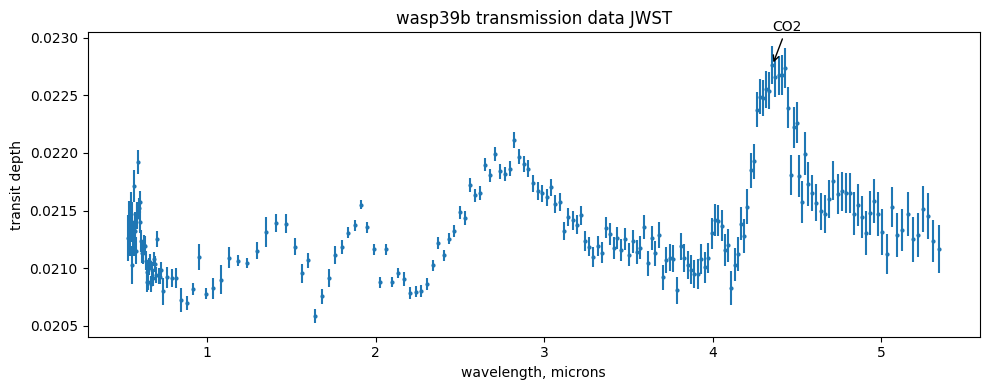

In [32]:
fig,ax = plt.subplots(figsize=(10,4))
ax.errorbar(wl, depth, yerr=err,fmt="o",markersize=2)
ax.set_xlabel("wavelength, microns")
ax.set_ylabel("transit depth")
ax.set_title("wasp39b transmission data JWST")
ax.annotate("CO2", xy=(wl[co2_idx], depth[co2_idx]),xytext=(wl[co2_idx], depth[co2_idx] + 0.0003)
            ,arrowprops=dict(arrowstyle='->'))
plt.tight_layout()
plt.show()

In [33]:
def forward_model(wl, co2_amp, water_amp, baseline=0.0214):
    co2   = co2_amp   * np.exp(-((wl - 4.3)**2) / (2 * 0.10**2))
    w1    = water_amp * np.exp(-((wl - 1.4)**2) / (2 * 0.15**2))
    w2    = water_amp * np.exp(-((wl - 1.9)**2) / (2 * 0.12**2))
    w3    = water_amp * np.exp(-((wl - 2.7)**2) / (2 * 0.20**2))
    return baseline + co2 + w1 + w2 + w3

def chi_squared(co2_amp, water_amp):
    model = forward_model(wl, co2_amp, water_amp)
    return np.sum(((depth - model) / err)**2)

In [39]:
co2_grid   = np.linspace(0.00001, 0.0005, 100)
water_grid = np.linspace(0.00001, 0.0005, 100)

chi2_map = np.zeros((len(co2_grid), len(water_grid)))

for i, co2_amp in enumerate(co2_grid):
    for j, water_amp in enumerate(water_grid):
        chi2_map[i, j] = chi_squared(co2_amp, water_amp)

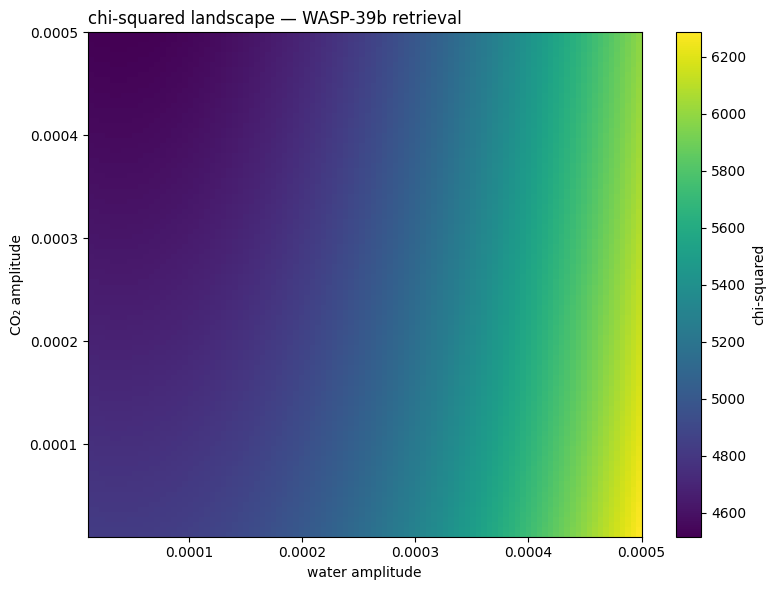

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(chi2_map, origin='lower', aspect='auto',
               extent=[water_grid.min(), water_grid.max(),
                       co2_grid.min(), co2_grid.max()],
               cmap='viridis')

plt.colorbar(im, ax=ax, label='chi-squared')
ax.set_xlabel('water amplitude')
ax.set_ylabel('CO₂ amplitude')
ax.set_title('chi-squared landscape — WASP-39b retrieval', 
             fontweight='normal', loc='left')

plt.tight_layout()
plt.savefig('wasp39b_chi2_map.png', dpi=150, bbox_inches='tight')
plt.show()

Best CO₂ amplitude: 0.000500
Best water amplitude: 0.000035
Best chi-squared: 4516.6


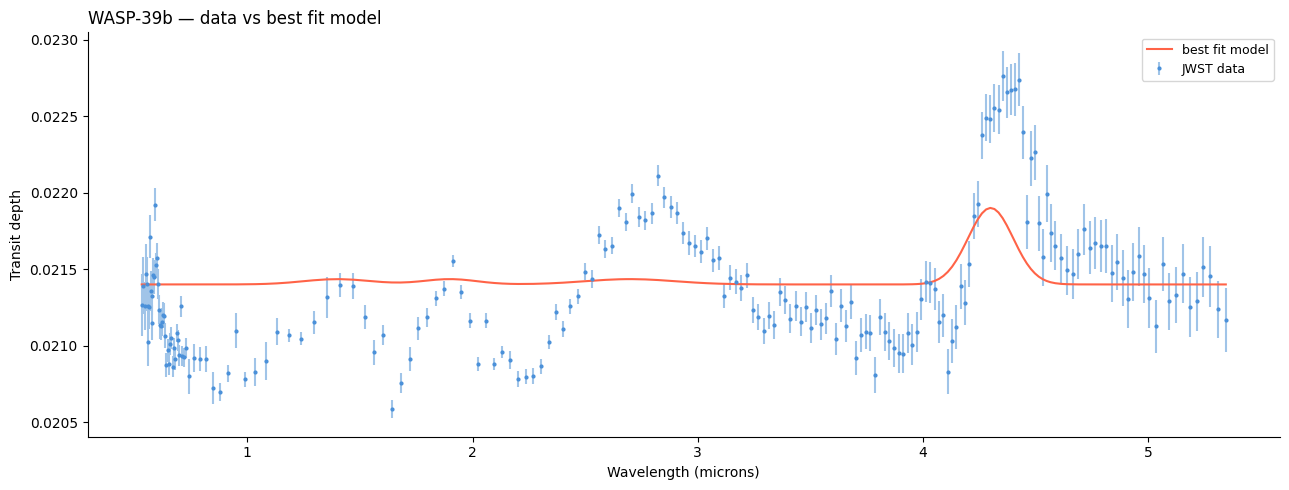

In [41]:
# find best fit parameters
best_idx = np.unravel_index(np.argmin(chi2_map), chi2_map.shape)
best_co2   = co2_grid[best_idx[0]]
best_water = water_grid[best_idx[1]]

print(f"Best CO₂ amplitude: {best_co2:.6f}")
print(f"Best water amplitude: {best_water:.6f}")
print(f"Best chi-squared: {chi2_map[best_idx]:.1f}")

# plot
best_model = forward_model(wl, best_co2, best_water)

fig, ax = plt.subplots(figsize=(13, 5))
ax.errorbar(wl, depth, yerr=err, fmt='o', markersize=2, 
            color='#4a90d9', ecolor='#a0c4e8', label='JWST data')
ax.plot(wl, best_model, color='tomato', linewidth=1.5, label='best fit model')
ax.set_xlabel('Wavelength (microns)', fontsize=10)
ax.set_ylabel('Transit depth', fontsize=10)
ax.set_title('WASP-39b — data vs best fit model', fontweight='normal', loc='left')
ax.legend(fontsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()